# Assignment Sesi 12
Nama: Faraday Barr Fatahillah

Instruksi

Anda bekerja sebagai analis properti. Klien Anda adalah investor yang ingin memahami karakteristik harga rumah di California sebelum membuat keputusan investasi. Klien tidak berlatar belakang data, jadi setiap angka harus disertai penjelasan yang mudah dipahami.

Target variabel utama adalah kolom MedHouseVal (median harga rumah dalam ratusan ribu dolar).

In [22]:
#Load Dataset
from sklearn.datasets import fetch_california_housing 
import pandas as pd 

data = fetch_california_housing(as_frame=True) 

df = data.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Task 1 — Ukuran tendensi sentral**
1. Hitung mean, median, dan modus dari kolom MedHouseVal. Hitung secara manual menggunakan formula Python dasar (bukan .mean() atau .median()), lalu verifikasi hasilnya menggunakan method Pandas. Cetak kedua hasil dan konfirmasi hasilnya sama.
2. Buat histogram MedHouseVal dengan bins=50. Gambarkan garis vertikal untuk mean dan median. Dari visualisasi ini, apakah distribusinya right-skewed, left-skewed, atau mendekati normal? Jelaskan di markdown.
3. Berdasarkan bentuk distribusi, ukuran mana yang lebih representatif sebagai 'harga tipikal' di California: mean atau median? Jelaskan dalam 2 kalimat yang bisa dipahami investor awam.

In [23]:
#Task 1.1
from collections import Counter #Untuk modus

values = df['MedHouseVal'].values

#Mean
mean_trad = sum(values) / len(values)
# print(mean_trad)

#Sort
sorted_values = sorted(values)
n = len(sorted_values)
# print(n)

#Median
median_trad = (sorted_values[n//2 - 1] + sorted_values[n//2])/2
# print(median_trad)

#Modus
counts = Counter(sorted_values)
mode_trad, count = counts.most_common(1)[0]
# print(mode_trad)
# print(count)

mean_pd = df['MedHouseVal'].mean()
median_pd = df['MedHouseVal'].median()
mode_pd = df['MedHouseVal'].mode()[0]

#Compare
print('Metode Tradisional')
print(f'Mean: {mean_trad}\nMedian: {median_trad}\nModus: {mode_trad}')

print('')
print('Metode Tradisional')
print(f'Mean: {mean_pd}\nMedian: {median_pd}\nModus: {mode_pd}')



Metode Tradisional
Mean: 2.0685581690891843
Median: 1.797
Modus: 5.00001

Metode Tradisional
Mean: 2.0685581690891475
Median: 1.797
Modus: 5.00001


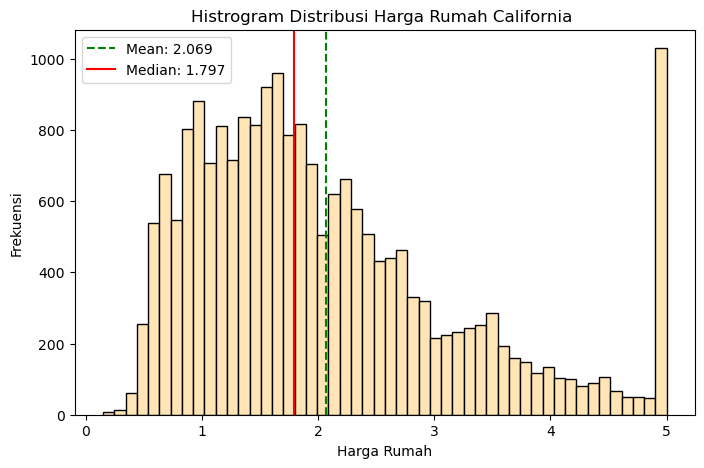

In [24]:
#Task 1.2
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))
plt.hist(df['MedHouseVal'], bins=50, edgecolor='black', color='moccasin')

plt.axvline(mean_trad, color='green', linestyle='--', label=f'Mean: {mean_trad:.3f}')
plt.axvline(median_trad, color='red', linestyle='-', label=f'Median: {median_trad}')

plt.title('Histrogram Distribusi Harga Rumah California ')
plt.xlabel('Harga Rumah')
plt.ylabel('Frekuensi')
plt.xticks(np.arange(0, 6, 1))
plt.legend()

plt.show()

Answer:\
Tabel di atas memiliki distribusi right-skewed dengan lonjakan data pada value '5'

**#Task 1.3**\
Answer:\
Harga median lebih cocok sebagai representasi harga tipikal karena tidak terpengaruh dengan lonjakan harga yang yang sangat mahal dan rata-rata menjadi lebih tinggi karena ada lonjakan harga tersebut.

**Task 2 — Ukuran sebaran**
1. Hitung untuk kolom MedHouseVal: standar deviasi, variansi, range (max - min), IQR (Q3 - Q1), dan persentil ke-10, ke-25, ke-75, dan ke-90.
2. Buat boxplot MedHouseVal. Tandai secara manual batas bawah dan atas outlier menggunakan garis horizontal (plt.axhline()). Batas outlier: di bawah Q1 - 1.5*IQR atau di atas Q3 + 1.5*IQR.
3. Hitung jumlah dan persentase baris yang masuk kategori outlier berdasarkan definisi di atas. Cetak hasilnya.

In [25]:
#Task 2.1
col = df['MedHouseVal']

std = col.std()
variance = col.var()
min_val = col.min()
max_val = col.max()
data_range = max_val - min_val

q1 = col.quantile(0.25)
q3 = col.quantile(0.75)
iqr = q3 - q1

percentile_10 = col.quantile(0.1)
percentile_25 = q1
percentile_75 = q3
percentile_90 = col.quantile(0.9)

print(f'Standar Deviasi: {std}')
print(f'Variansi: {variance}')
print(f'Range: {data_range}')
print(f'Min: {min_val}')
print(f'Max: {max_val}')
print(f'IQR: {iqr}')
print(f'Persentil 10: {percentile_10}')
print(f'Persentil 25: {percentile_25}')
print(f'Persentil 75: {percentile_75}')
print(f'Persentil 90: {percentile_90}')

Standar Deviasi: 1.1539561587441385
Variansi: 1.3316148163035275
Range: 4.85002
Min: 0.14999
Max: 5.00001
IQR: 1.4512499999999997
Persentil 10: 0.823
Persentil 25: 1.196
Persentil 75: 2.6472499999999997
Persentil 90: 3.766


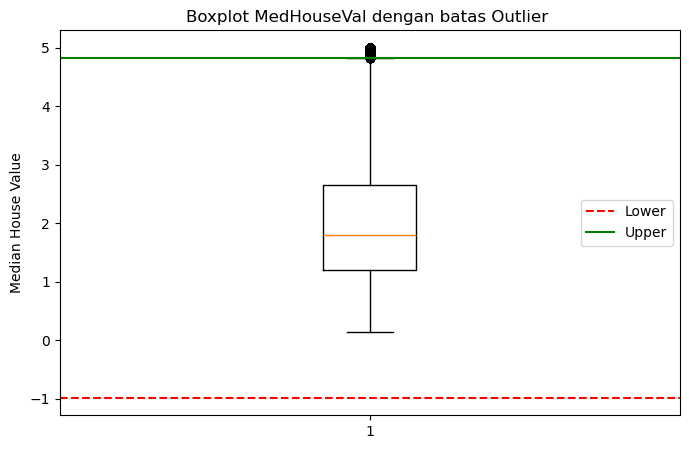

In [26]:
#Task 2.2
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

plt.figure(figsize=(8,5))
plt.boxplot(col, vert=True)

plt.axhline(lower, color='red', linestyle='--', label='Lower')
plt.axhline(upper, color='green', linestyle='-', label='Upper')

plt.title('Boxplot MedHouseVal dengan batas Outlier ')
plt.ylabel('Median House Value')
plt.legend()

plt.show()

In [27]:
#Task 2.3
outlier = col[(col < lower) | (col > upper)]

noutlier = len(outlier)

percent_outlier = noutlier/(len(col)) * 100

print(f'Jumlah outlier: {noutlier}\nPersentase outlier: {percent_outlier:.2f}%')

Jumlah outlier: 1071
Persentase outlier: 5.19%


**Task 3 — Perbandingan antar kelompok**
1. Dataset punya kolom OceanProximity (kedekatan dengan laut). Hitung mean, median, dan standar deviasi MedHouseVal untuk setiap kategori OceanProximity. Tampilkan sebagai DataFrame yang rapi.
2. Buat violin plot yang membandingkan distribusi MedHouseVal per kategori OceanProximity. Urutkan kategori berdasarkan median MedHouseVal dari tertinggi ke terendah.
3. Hitung coefficient of variation (CV = standar deviasi / mean * 100) untuk setiap kategori. Kategori mana yang harga rumahnya paling bervariasi? Cetak hasilnya.

In [32]:
"""Tidak bisa dilakukan dataset berubah alias sudah tidak ada OceanProximity lagi Cek: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html
"""

'Tidak bisa dilakukan dataset berubah alias sudah tidak ada OceanProximity lagi Cek: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html\n'

**Task 4 — Laporan untuk investor**\
Di cell markdown di akhir notebook, tulis ringkasan 1 halaman untuk investor dengan struktur:
1. Gambaran umum harga rumah di California (gunakan angka dari Task 1 dan Task 2).
2. Kategori lokasi mana yang paling mahal dan paling terjangkau berdasarkan Task 3.
3. Risiko investasi: lokasi mana yang harganya paling tidak stabil (CV tertinggi)?
4. Gunakan bahasa non-teknis. Hindari jargon seperti 'standar deviasi' dan ganti dengan penjelasannya, contoh: 'harga antar rumah bervariasi hingga X dolar dari rata-rata'.

**#Task 4.1**\
Answer:\
Dapat dilihat dari grafik yang ada di task 1 dan di task 2, harga rumah di California berada di kisaran menengah dengan harga tipikal sekitar $180,000 (sepertinya ribu bukan juat atau miliar), sementara rata-rata harga sedikit lebih tinggi sekitar $207,000 dollar karena adanya beberapa rumah dengan harga yang sangat mahal. Perbedaan harga termurah dan termahal cukup besar juga, yaitu $15,000 hingga $500,000 yang menandakan pasar properti di California sangat beragam. Sekitar 50% rumah berada di kisaran $120,000 hingga $265,000 yang dapat dianggap sebagai mayoritas harga di pasar. Selain itu ada juga beberapa rumah yang kemungkinan berada di area lebih elit sehingga investor memiliki peluang investasi baik di segmen menengah maupun atas, namun dengan karakteristik pasar yang berbeda.